In [1]:
pip install util-gfsilveira

In [2]:
#gerar gráfico
import matplotlib
#estruturação dos dados
import numpy as np
#gerar gráfico
import seaborn as sns
#gerar gráfico
import matplotlib.pyplot as plt
#Carregar o modelo
from keras.models import load_model
#salvar/carregar arquivos em diferentes formatos
import joblib

In [ ]:
#Importando o modelo contendo os valores previstos para o número de células nas imagens
modelo_maior_erro = load_model('/content/drive/MyDrive/teste/imagens_julia_quantificacao/lista de imagens e rótulos - contraste digital/img_e_rot_para_validação_contraste/modelo_fluore_100_75_50_25_2024-9-10.keras')
modelo_maior_erro

<Sequential name=sequential, built=True>

In [ ]:
X_test_maior_erro = joblib.load('/content/drive/MyDrive/teste/imagens_julia_quantificacao/lista de imagens e rótulos - contraste digital/img_e_rot_para_validação_contraste/imagens_validação_10%_fluore_2024-9-10.gz') #carregando arquivo
X_test_maior_erro.shape

(63, 300, 300, 3)

In [ ]:
y_test_maior_erro = joblib.load('/content/drive/MyDrive/teste/imagens_julia_quantificacao/lista de imagens e rótulos - contraste digital/img_e_rot_para_validação_contraste/rótulos_validação_10%_fluore_2024-9-10.gz') #carregando arquivo
y_test_maior_erro.shape

(63,)

In [ ]:
#ROTULOS SALVOS EM LISTA

lista_observado_maior_erro = list(y_test_maior_erro)
len(lista_observado_maior_erro)

63

In [ ]:
#PREDIÇÃO SALVO EM LISTA

dados_prev = modelo_maior_erro.predict(X_test_maior_erro)
lista_previsto_maior_erro = dados_prev.flatten().tolist()
len(lista_previsto_maior_erro)

2/2 ━━━━━━━━━━━━━━━━━━━━ 20s 9s/step


63

In [ ]:
import pandas as pd
from scipy.stats.stats import pearsonr as stats

<ipython-input-8-b12f1aff8071>:2: DeprecationWarning: Please import `pearsonr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import pearsonr as stats


In [ ]:
#DATAFRAME - ORGANIZAÇÃO DAS LISTAS
#COLUNA 1 ROTULO/ COLUNA 2 PREDITO

df_maior_erro = pd.DataFrame(zip(lista_observado_maior_erro,lista_previsto_maior_erro),
                             columns = ['Observed values','Lista preditos'])
df_maior_erro.head()

,Observed values,Lista preditos
0,588,532.255005
1,712,577.830811
2,275,283.196381
3,701,722.472656
4,306,449.665405


In [ ]:
#ARREDONDANDO O PREDITO ('lista preditos')

teste = round(df_maior_erro['Lista preditos'],2)
df_maior_erro['Predicted values'] = teste
df_maior_erro.head()

,Observed values,Lista preditos,Predicted values
0,588,532.255005,532.26
1,712,577.830811,577.83
2,275,283.196381,283.20
3,701,722.472656,722.47
4,306,449.665405,449.67


In [ ]:
#REORGANIZANDO AS COLUNAS

df_maior_erro = df_maior_erro.reindex(columns=['Observed values','Predicted values','Lista preditos'])
df_maior_erro.head()

,Observed values,Predicted values,Lista preditos
0,588,532.26,532.255005
1,712,577.83,577.830811
2,275,283.20,283.196381
3,701,722.47,722.472656
4,306,449.67,449.665405


In [ ]:
#BIBLIOTECA CORRELAÇÃO
from scipy.stats.stats import spearmanr as spearman #importando a biblioteca para gráfico de correlação

<ipython-input-12-b2b9a789bed1>:2: DeprecationWarning: Please import `spearmanr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import spearmanr as spearman #importando a biblioteca para gráfico de correlação


In [ ]:
# #CALCULO DE CORRELAÇÃO

col1_obt = 0 #Observed value
col2_prev = 1 #Predicted values
pear_pos_maior_erro = stats(df_maior_erro[df_maior_erro.columns[col1_obt]],
                            df_maior_erro[df_maior_erro.columns[col2_prev]])

TypeError: unsupported operand type(s) for +: 'float' and 'numpy.str_'

In [ ]:
from scipy import stats

# Verifique se as colunas contêm apenas valores numéricos
df_maior_erro[df_maior_erro.columns[col1_obt]] = pd.to_numeric(df_maior_erro[df_maior_erro.columns[col1_obt]], errors='coerce')
df_maior_erro[df_maior_erro.columns[col2_prev]] = pd.to_numeric(df_maior_erro[df_maior_erro.columns[col2_prev]], errors='coerce')

# Remova as linhas com valores NaN resultantes da conversão
df_maior_erro = df_maior_erro.dropna(subset=[df_maior_erro.columns[col1_obt], df_maior_erro.columns[col2_prev]])

# Calcular a correlação
pear_pos_maior_erro = stats.pearsonr(df_maior_erro[df_maior_erro.columns[col1_obt]],
                                     df_maior_erro[df_maior_erro.columns[col2_prev]])

print(pear_pos_maior_erro)

PearsonRResult(statistic=0.9046896318618824, pvalue=2.8047398834768113e-24)


<Figure size 1500x1500 with 0 Axes>

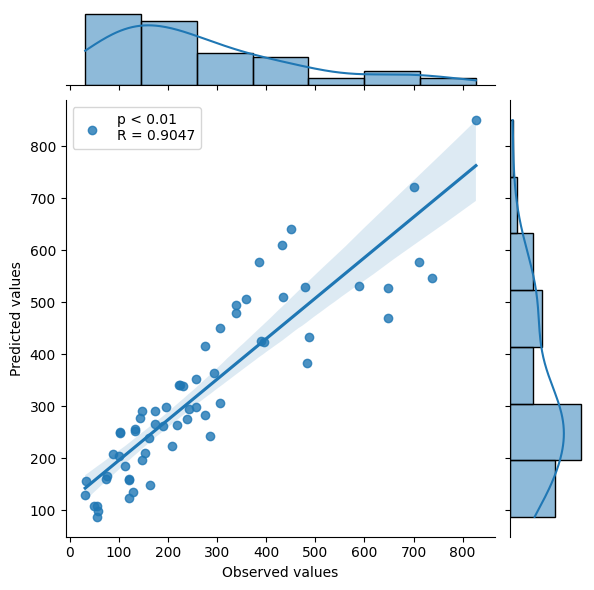

In [ ]:
plt.figure(figsize=(15,15))
sns.jointplot(
    x=df_maior_erro.columns[col1_obt],
    y=df_maior_erro.columns[col2_prev],
    kind='reg',
    data=df_maior_erro#[df_maior_erro['Lista observado'] > 300]
)

if pear_pos_maior_erro[1] < 0.01:
  plt.legend(['p < ' + '0.01' + '\nR = ' + str(round(pear_pos_maior_erro[0], 4))]) #calculando p e relse:
else:
  plt.legend(['p = ' + str(round(pear_pos_maior_erro[1],4)) + '\nR = ' + str(round(pear_pos_maior_erro[0], 4))]) #calculando p e r

#Predição do modelo

In [ ]:
predictions = modelo_maior_erro.predict(X_test_maior_erro)

2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 6s/step


In [ ]:
# Compara as previsões com os valores reais
for i in range(len(predictions)):
    print(f"Valor real: {y_test_maior_erro[i]}, Valor predito: {predictions[i]}")

Valor real: 588, Valor predito: [532.255]
Valor real: 712, Valor predito: [577.8308]
Valor real: 275, Valor predito: [283.19638]
Valor real: 701, Valor predito: [722.47266]
Valor real: 306, Valor predito: [449.6654]
Valor real: 190, Valor predito: [262.01825]
Valor real: 435, Valor predito: [511.0346]
Valor real: 648, Valor predito: [469.88458]
Valor real: 827, Valor predito: [850.44934]
Valor real: 483, Valor predito: [383.25653]
Valor real: 195, Valor predito: [297.84668]
Valor real: 285, Valor predito: [242.05742]
Valor real: 478, Valor predito: [528.5963]
Valor real: 648, Valor predito: [527.3637]
Valor real: 738, Valor predito: [546.1961]
Valor real: 305, Valor predito: [305.83417]
Valor real: 450, Valor predito: [641.4288]
Valor real: 432, Valor predito: [609.72076]
Valor real: 101, Valor predito: [249.88342]
Valor real: 173, Valor predito: [289.90814]
Valor real: 143, Valor predito: [276.5514]
Valor real: 132, Valor predito: [257.10977]
Valor real: 230, Valor predito: [339.79834

#Predição de Frequência Absoluta

In [ ]:
df_maior_erro


,Observed values,Predicted values,Lista preditos
0,588,532.26,532.255005
1,712,577.83,577.830811
2,275,283.20,283.196381
3,701,722.47,722.472656
4,306,449.67,449.665405
...,...,...,...
58,120,123.73,123.725082
59,147,196.58,196.579956
60,75,165.51,165.507416
61,49,107.59,107.592300


In [ ]:
df_maior_erro['Diferença'] = df_maior_erro['Observed values'] - df_maior_erro['Predicted values']

In [ ]:
df_maior_erro

,Observed values,Predicted values,Lista preditos,Diferença
0,588,532.26,532.255005,55.74
1,712,577.83,577.830811,134.17
2,275,283.20,283.196381,-8.20
3,701,722.47,722.472656,-21.47
4,306,449.67,449.665405,-143.67
...,...,...,...,...
58,120,123.73,123.725082,-3.73
59,147,196.58,196.579956,-49.58
60,75,165.51,165.507416,-90.51
61,49,107.59,107.592300,-58.59


In [ ]:
import matplotlib.pyplot as plt

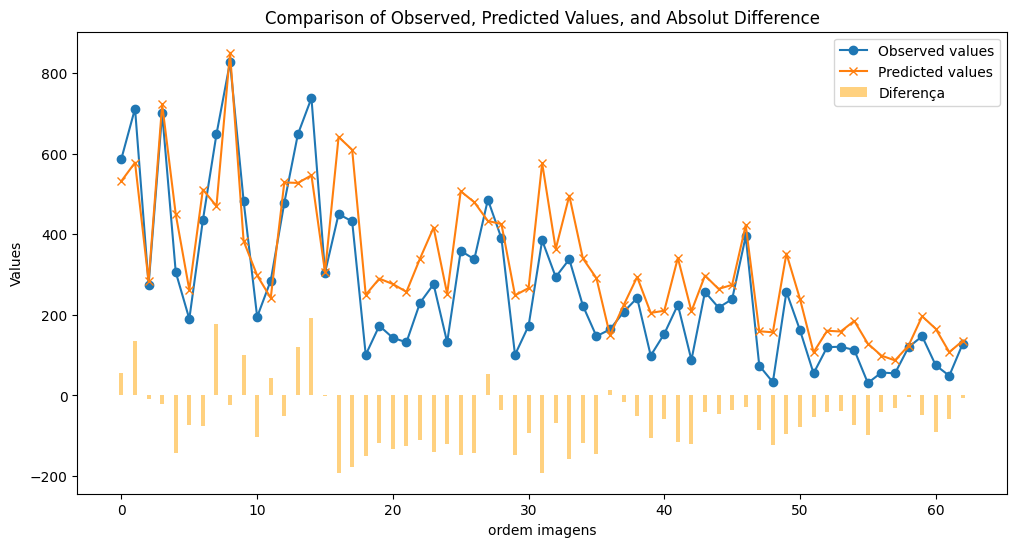

In [ ]:
plt.figure(figsize=(12, 6))

# Plotando os valores observados e preditos
plt.plot(df_maior_erro.index, df_maior_erro['Observed values'], label='Observed values', marker='o')
plt.plot(df_maior_erro.index, df_maior_erro['Predicted values'], label='Predicted values', marker='x')

# Adiciona a linha da diferença
plt.bar(df_maior_erro.index, df_maior_erro['Diferença'], width=0.3, alpha=0.5, label='Diferença', color='orange')

# Adiciona rótulos e título
plt.xlabel('ordem imagens')
plt.ylabel('Values')
plt.title('Comparison of Observed, Predicted Values, and Absolut Difference')
plt.legend()

# Mostra o gráfico
plt.show()

**Interpretação**:
* No gráfico, você pode ver que as linhas de "Observed Values" e "Predicted Values" estão bastante próximas na maioria dos pontos, o que indica que o modelo está realizando previsões com boa precisão.
* No entanto, existem algumas discrepâncias visíveis, evidenciadas pelas barras de "Difference". As barras amarelas variam em magnitude e sinal, mostrando onde e em que medida o modelo errou.
* Quando as barras estão próximas de zero, o modelo fez previsões muito próximas dos valores reais. Já nas áreas onde as barras são mais altas ou baixas, as previsões do modelo se distanciaram dos valores observados.

**Conclusão**:
Esse gráfico permite avaliar visualmente o desempenho do modelo de regressão. A proximidade das linhas de valores observados e preditos sugere que o modelo está funcionando bem, mas as barras de diferença ajudam a identificar onde ele comete erros e quão grandes são esses erros.

#Previsão Frequência Relativa (%)

In [ ]:
#Calcula a diferença relativa entre o valor real e o valor predito (em %)
# df_maior_erro['Relative Difference (%)'] = ((df_maior_erro['Observed values'] - df_maior_erro['Predicted values']) / df_maior_erro['Observed values']) * 100
# df_maior_erro.head()

In [ ]:
df_maior_erro['Relative Difference (%)'] = ((df_maior_erro['Predicted values']*100) / df_maior_erro['Observed values'])
df_maior_erro.head()

,Observed values,Predicted values,Lista preditos,Diferença,Relative Difference (%)
0,588,532.26,532.255005,55.74,90.520408
1,712,577.83,577.830811,134.17,81.155899
2,275,283.20,283.196381,-8.20,102.981818
3,701,722.47,722.472656,-21.47,103.062767
4,306,449.67,449.665405,-143.67,146.950980


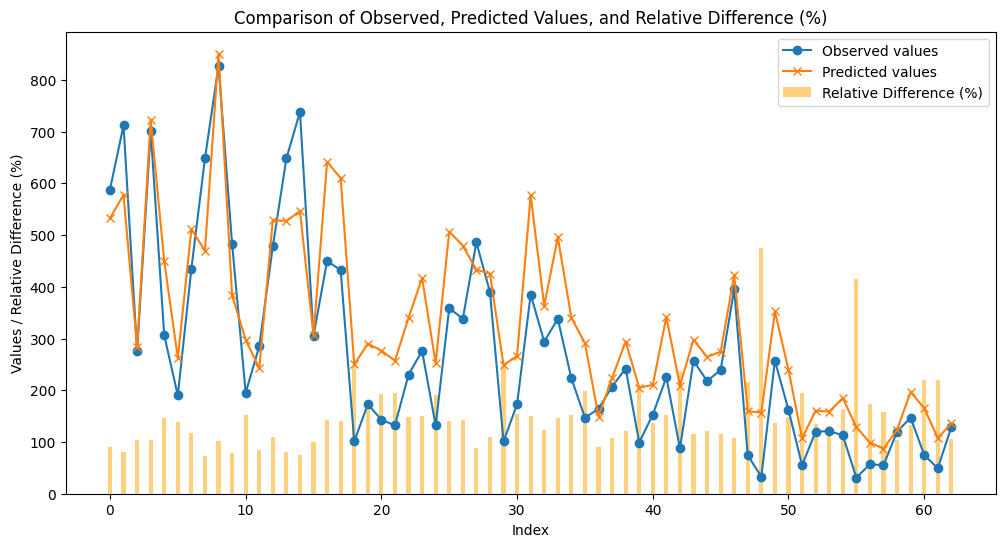

In [ ]:
# Cria o gráfico comparando os valores
plt.figure(figsize=(12, 6))

# Plotando os valores observados e preditos
plt.plot(df_maior_erro.index, df_maior_erro['Observed values'], label='Observed values', marker='o')
plt.plot(df_maior_erro.index, df_maior_erro['Predicted values'], label='Predicted values', marker='x')

# Adiciona a linha da diferença relativa
plt.bar(df_maior_erro.index, df_maior_erro['Relative Difference (%)'], width=0.3, alpha=0.5, label='Relative Difference (%)', color='orange')

# Adiciona rótulos e título
plt.xlabel('Index')
plt.ylabel('Values / Relative Difference (%)')
plt.title('Comparison of Observed, Predicted Values, and Relative Difference (%)')
plt.legend()

# Mostra o gráfico
plt.show()

**Explicação**:
1. Diferença Relativa: A diferença relativa é calculada dividindo a diferença absoluta pelo valor observado e multiplicando por 100 para expressá-la como uma porcentagem.
2. Gráfico de Barras para Diferença Relativa: As barras agora representam a diferença em termos percentuais (%), mostrando onde o modelo previu valores maiores ou menores em relação aos valores reais.
3. Outros Detalhes: As linhas dos valores observados e preditos permanecem as mesmas para facilitar a comparação, mas o foco aqui está nas barras de diferença relativa.

**Interpretação**:
* Esse gráfico ajudará a visualizar melhor os erros em termos proporcionais, o que é útil especialmente quando os valores observados variam bastante. A análise de erro em termos percentuais permite ver onde o modelo está errando mais, independentemente da magnitude dos valores absolutos.

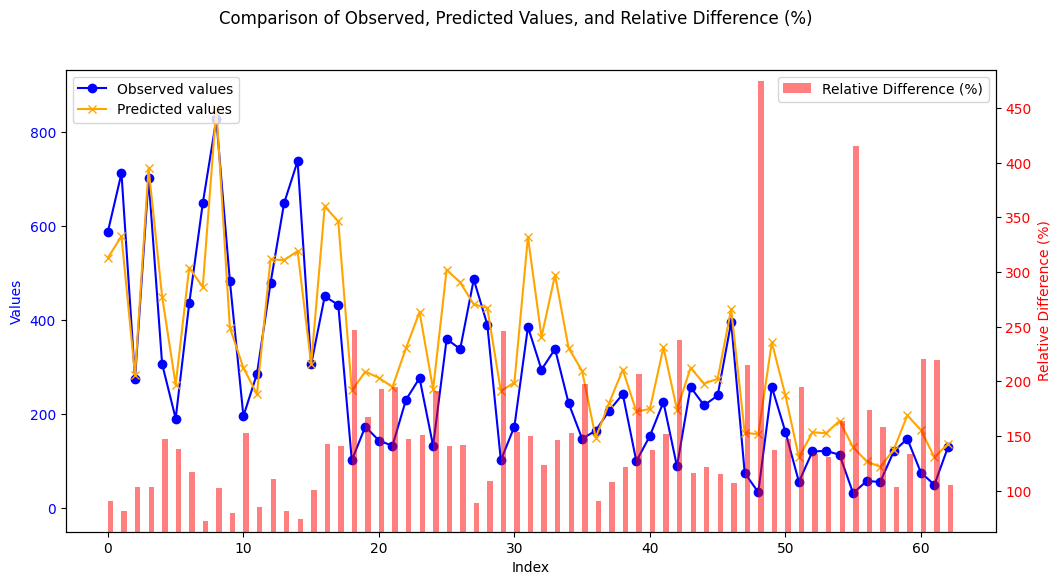

In [ ]:
# Cria o gráfico com dois eixos Y
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eixo Y da esquerda (para valores observados e preditos)
ax1.set_xlabel('Index')
ax1.set_ylabel('Values', color='blue')
ax1.plot(df_maior_erro.index, df_maior_erro['Observed values'], label='Observed values', marker='o', color='blue')
ax1.plot(df_maior_erro.index, df_maior_erro['Predicted values'], label='Predicted values', marker='x', color='orange')
ax1.tick_params(axis='y', labelcolor='blue')

# Ajusta o limite do eixo Y da esquerda para aumentar a escala
y_min = df_maior_erro[['Observed values', 'Predicted values']].min().min()
y_max = df_maior_erro[['Observed values', 'Predicted values']].max().max()
ax1.set_ylim([y_min - 0.1 * (y_max - y_min), y_max + 0.1 * (y_max - y_min)])

# Adiciona o segundo eixo Y à direita (para diferença relativa)
ax2 = ax1.twinx()
ax2.set_ylabel('Relative Difference (%)', color='red')
# Ajusta a largura das barras
bar_width = 0.4
ax2.bar(df_maior_erro.index + bar_width / 2, df_maior_erro['Relative Difference (%)'], width=bar_width, alpha=0.5, label='Relative Difference (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')


# Ajusta o limite do eixo Y da direita para melhor visualização das barras
ax2.set_ylim([df_maior_erro['Relative Difference (%)'].min() - 10,
              df_maior_erro['Relative Difference (%)'].max() + 10])

# Títulos e legendas
fig.suptitle('Comparison of Observed, Predicted Values, and Relative Difference (%)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Mostra o gráfico
plt.show()

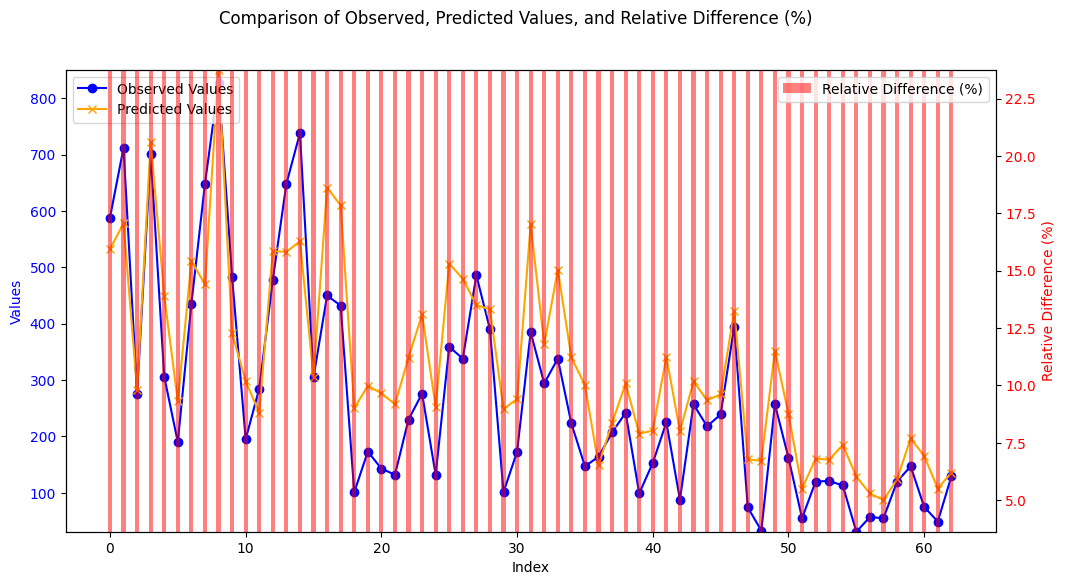

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eixo Y da esquerda (para valores observados e preditos)
ax1.set_xlabel('Index')
ax1.set_ylabel('Values', color='blue')
ax1.plot(df_maior_erro.index, df_maior_erro['Observed values'], label='Observed Values', marker='o', color='blue')
ax1.plot(df_maior_erro.index, df_maior_erro['Predicted values'], label='Predicted Values', marker='x', color='orange')
ax1.tick_params(axis='y', labelcolor='blue')

# Mantém a escala normal do eixo Y da esquerda
ax1.set_ylim(df_maior_erro[['Observed values', 'Predicted values']].min().min(),
             df_maior_erro[['Observed values', 'Predicted values']].max().max())

# Adiciona o segundo eixo Y à direita (para diferença relativa)
ax2 = ax1.twinx()
ax2.set_ylabel('Relative Difference (%)', color='red')

# Ajusta a largura das barras e reduz bastante a altura das barras
bar_width = 0.3
ax2.bar(df_maior_erro.index, df_maior_erro['Relative Difference (%)'], width=bar_width, alpha=0.5, label='Relative Difference (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Diminui bastante a altura das barras do eixo direito ajustando a escala
ax2.set_ylim(df_maior_erro['Relative Difference (%)'].min() * 0.05, df_maior_erro['Relative Difference (%)'].max() * 0.05)  # Reduz em 95%

# Títulos e legendas
fig.suptitle('Comparison of Observed, Predicted Values, and Relative Difference (%)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Mostra o gráfico
plt.show()

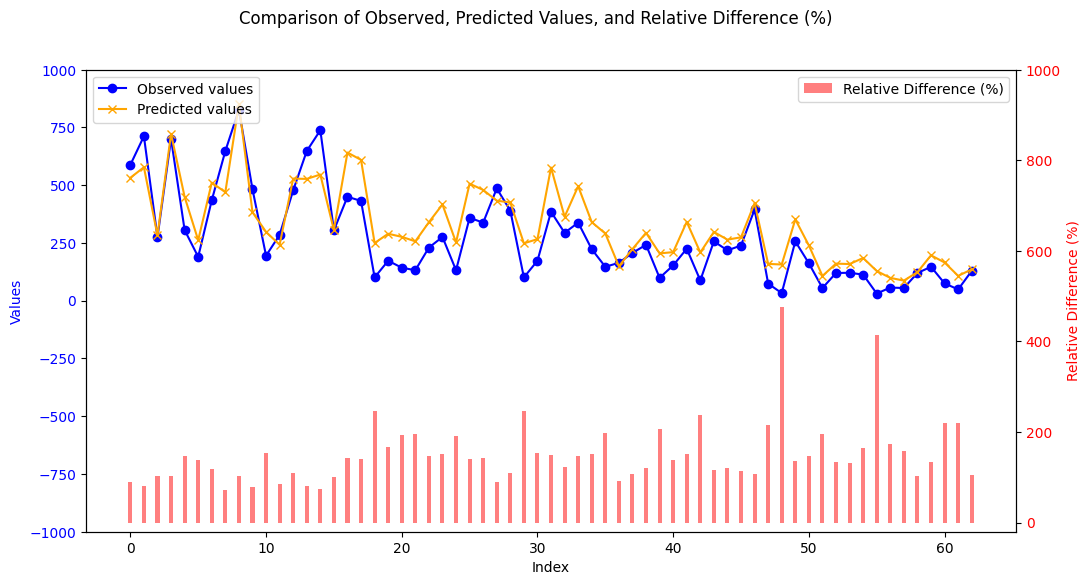

In [ ]:
# Cria o gráfico com dois eixos Y
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eixo Y da esquerda (para valores observados e preditos)
ax1.set_xlabel('Index')
ax1.set_ylabel('Values', color='blue')
ax1.plot(df_maior_erro.index, df_maior_erro['Observed values'], label='Observed values', marker='o', color='blue')
ax1.plot(df_maior_erro.index, df_maior_erro['Predicted values'], label='Predicted values', marker='x', color='orange')
ax1.tick_params(axis='y', labelcolor='blue')

# Mantém a escala normal do eixo Y da esquerda
# ax1.set_ylim(df_maior_erro[['Observed values', 'Predicted values']].min().min(),
#              df_maior_erro[['Observed values', 'Predicted values']].max().max())
ax1.set_ylim(-1000, 1000)

# Adiciona o segundo eixo Y à direita (para diferença relativa)
ax2 = ax1.twinx()
ax2.set_ylabel('Relative Difference (%)', color='red')


# Ajusta a largura das barras
bar_width = 0.3
ax2.bar(df_maior_erro.index, df_maior_erro['Relative Difference (%)'], width=bar_width, alpha=0.5, label='Relative Difference (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Corrige a amplitude do eixo Y da direita para -15 a 300
ax2.set_ylim(-20, 1000)

# Títulos e legendas
fig.suptitle('Comparison of Observed, Predicted Values, and Relative Difference (%)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Mostra o gráfico
plt.show()